In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 1. 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [3]:
# 2. 데이터 불러오기
file_path = "youth_employment.xlsx" 
df = pd.read_excel(file_path, sheet_name="년도별 정리")

In [4]:
# 데이터 전처리

# 완전 빈 행 삭제
df = df.dropna(how="all").reset_index(drop=True)

# 중복 헤더 행 삭제
df = df[df["변화폭"] != "변화폭"].reset_index(drop=True)

# 권역 공백 제거
df["권역"] = df["권역"].astype(str).str.replace(" ", "")

# 숫자형 변환
num_cols = [2022, 2023, 2024, 2025, "변화폭"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [5]:
df[num_cols] = df[num_cols].round(2)

In [6]:
pd.options.display.float_format = "{:.2f}".format

In [7]:
print("전처리 완료 데이터")
print(df)

전처리 완료 데이터
      시도별   권역  2022  2023  2024  2025   변화폭
0   서울특별시  수도권 51.53 51.82 51.18 49.10 -2.43
1   인천광역시  수도권 50.60 49.18 47.45 44.78 -5.83
2     경기도  수도권 49.98 49.88 49.45 46.68 -3.30
3   부산광역시   지방 42.00 43.88 46.12 44.10  2.10
4   대구광역시   지방 41.22 42.35 37.48 39.35 -1.88
5    전라북도   지방 38.60 38.83 38.02 37.98 -0.62
6  수도권 평균  수도권 50.70 50.29 49.36 46.85 -3.85
7   지방 평균   지방 40.61 41.68 40.54 40.47 -0.13


In [8]:
# 4. 지역 데이터 / 권역 평균 데이터 분리
df_city = df[~df["시도별"].str.contains("평균")].copy()
df_region = df[df["시도별"].str.contains("평균")].copy()

print("\n지역별 데이터")
print(df_city)

print("\n권역 평균 데이터")
print(df_region)


지역별 데이터
     시도별   권역  2022  2023  2024  2025   변화폭
0  서울특별시  수도권 51.53 51.82 51.18 49.10 -2.43
1  인천광역시  수도권 50.60 49.18 47.45 44.78 -5.83
2    경기도  수도권 49.98 49.88 49.45 46.68 -3.30
3  부산광역시   지방 42.00 43.88 46.12 44.10  2.10
4  대구광역시   지방 41.22 42.35 37.48 39.35 -1.88
5   전라북도   지방 38.60 38.83 38.02 37.98 -0.62

권역 평균 데이터
      시도별   권역  2022  2023  2024  2025   변화폭
6  수도권 평균  수도권 50.70 50.29 49.36 46.85 -3.85
7   지방 평균   지방 40.61 41.68 40.54 40.47 -0.13


In [9]:
# 5. 지역별 변화폭 정렬
df_city = df_city.sort_values("변화폭")

print("\n지역별 변화폭 정렬")
print(df_city[["시도별", "권역", "변화폭"]])


지역별 변화폭 정렬
     시도별   권역   변화폭
1  인천광역시  수도권 -5.83
2    경기도  수도권 -3.30
0  서울특별시  수도권 -2.43
4  대구광역시   지방 -1.88
5   전라북도   지방 -0.62
3  부산광역시   지방  2.10


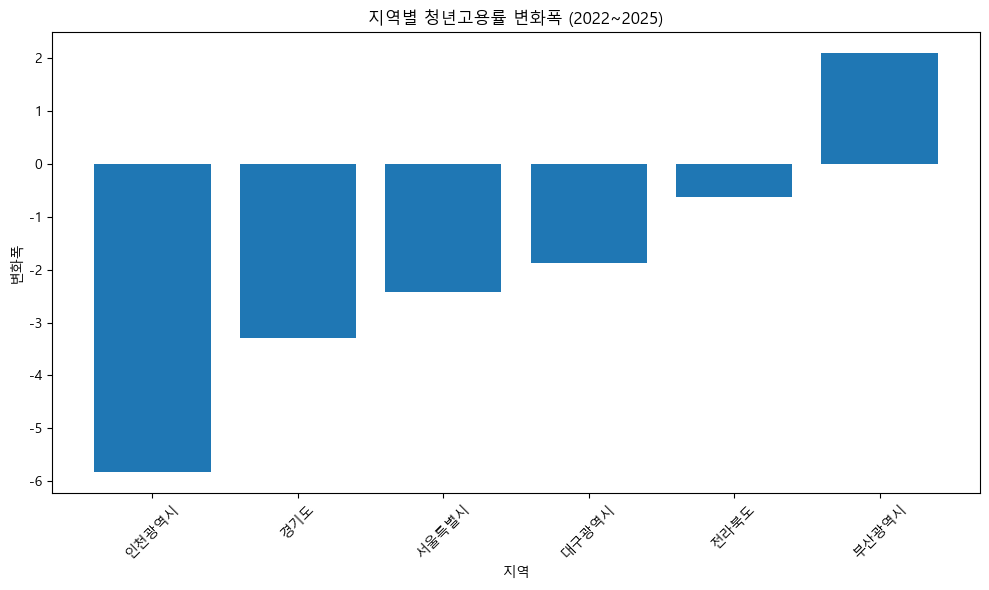

In [10]:
# 6. 지역별 변화폭 그래프
plt.figure(figsize=(10, 6))
plt.bar(df_city["시도별"], df_city["변화폭"])
plt.title("지역별 청년고용률 변화폭 (2022~2025)")
plt.xlabel("지역")
plt.ylabel("변화폭")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("city_change_plot.png", dpi=300, bbox_inches="tight")
plt.show()

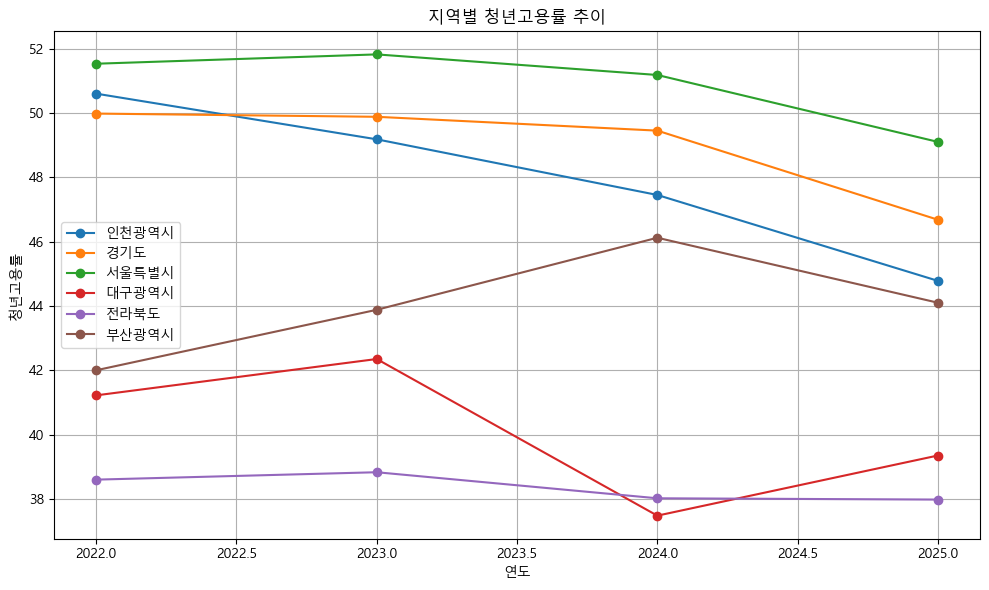

In [11]:
# 7. 지역별 연도별 추이 그래프
years = [2022, 2023, 2024, 2025]

plt.figure(figsize=(10, 6))
for i in range(len(df_city)):
    plt.plot(
        years,
        df_city.iloc[i][years],
        marker="o",
        label=df_city.iloc[i]["시도별"]
    )

plt.title("지역별 청년고용률 추이")
plt.xlabel("연도")
plt.ylabel("청년고용률")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("city_trend_plot.png", dpi=300, bbox_inches="tight")
plt.show()


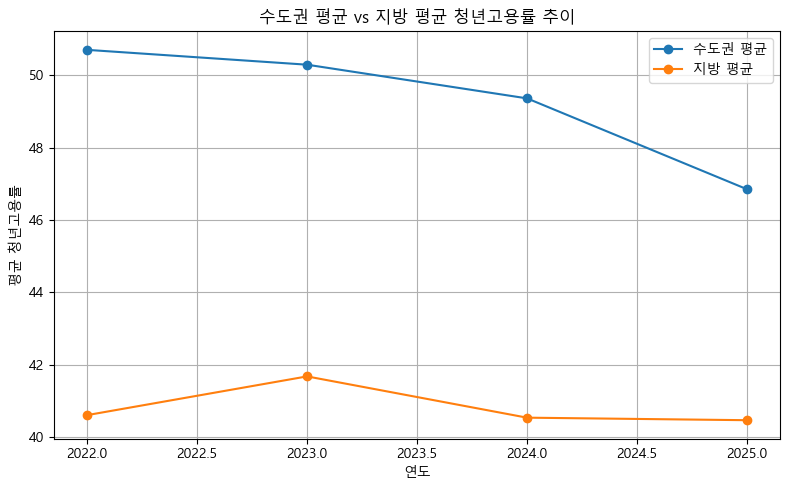

In [12]:
# 8. 수도권 평균 vs 지방 평균 그래프
plt.figure(figsize=(8, 5))
for i in range(len(df_region)):
    plt.plot(
        years,
        df_region.iloc[i][years],
        marker="o",
        label=df_region.iloc[i]["시도별"]
    )

plt.title("수도권 평균 vs 지방 평균 청년고용률 추이")
plt.xlabel("연도")
plt.ylabel("평균 청년고용률")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("region_avg_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# 9. 변동성 계산
year_cols = [2022, 2023, 2024, 2025]
df_city["변동성"] = df_city[year_cols].std(axis=1).round(2)

print("\n변동성 포함 데이터")
print(df_city[["시도별", 2025, "변화폭", "변동성"]])


변동성 포함 데이터
     시도별  2025   변화폭  변동성
1  인천광역시 44.78 -5.83 2.50
2    경기도 46.68 -3.30 1.56
0  서울특별시 49.10 -2.43 1.23
4  대구광역시 39.35 -1.88 2.14
5   전라북도 37.98 -0.62 0.42
3  부산광역시 44.10  2.10 1.68


In [14]:
# 10. 리스크 점수 계산
## 위험할수록 큰 점수가 되도록 설정
df_city["수준점수"] = df_city[2025].rank(ascending=False)       # 2025 값이 낮을수록 위험
df_city["하락점수"] = df_city["변화폭"].rank(ascending=False)    # 변화폭이 낮을수록 위험
df_city["변동성점수"] = df_city["변동성"].rank(ascending=True)   # 변동성이 클수록 위험

df_city["리스크점수"] = (
    df_city["수준점수"] +
    df_city["하락점수"] +
    df_city["변동성점수"]
).round(2)

In [15]:
# 11. 위험등급 분류
df_city["위험등급"] = pd.qcut(
    df_city["리스크점수"],
    q=3,
    labels=["저위험", "중위험", "고위험"]
)

In [16]:
# 12. 최종 결과표
result = df_city[["시도별", "권역", 2025, "변화폭", "변동성", "리스크점수", "위험등급"]] \
    .sort_values("리스크점수", ascending=False)

print("\n최종 결과표")
print(result)


최종 결과표
     시도별   권역  2025   변화폭  변동성  리스크점수 위험등급
1  인천광역시  수도권 44.78 -5.83 2.50  15.00  고위험
4  대구광역시   지방 39.35 -1.88 2.14  13.00  고위험
2    경기도  수도권 46.68 -3.30 1.56  10.00  중위험
5   전라북도   지방 37.98 -0.62 0.42   9.00  저위험
3  부산광역시   지방 44.10  2.10 1.68   9.00  저위험
0  서울특별시  수도권 49.10 -2.43 1.23   7.00  저위험


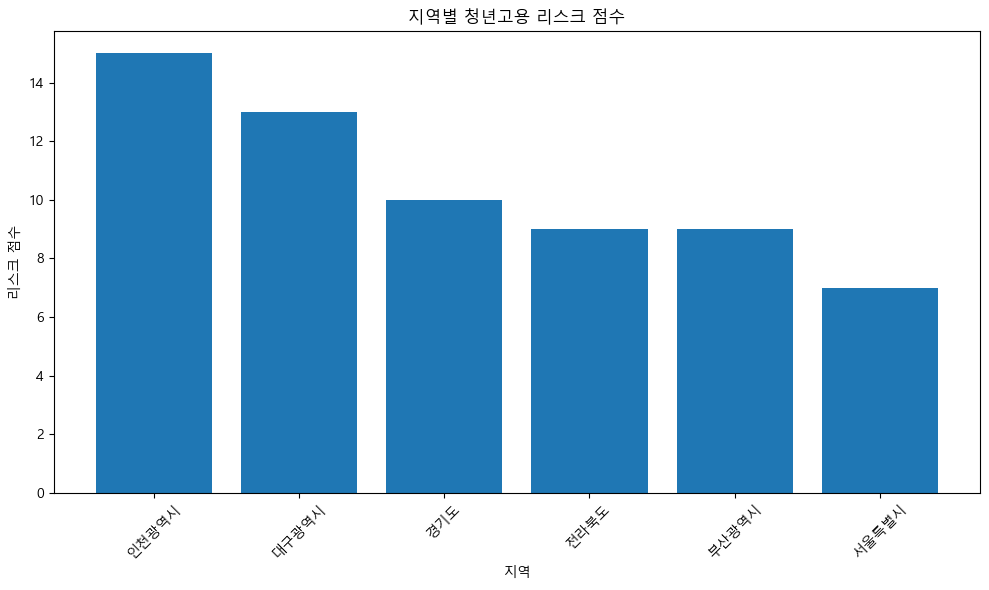

In [17]:
# 13. 리스크 점수 그래프
risk_df = result.copy()

plt.figure(figsize=(10, 6))
plt.bar(risk_df["시도별"], risk_df["리스크점수"])
plt.title("지역별 청년고용 리스크 점수")
plt.xlabel("지역")
plt.ylabel("리스크 점수")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("risk_score_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
# 14. 결과 저장
result.to_csv("youth_employment_risk_result.csv", index=False, encoding="utf-8-sig")

print("\n저장 완료:")
print("- youth_employment_risk_result.csv")
print("- city_change_plot.png")
print("- city_trend_plot.png")
print("- region_avg_plot.png")
print("- risk_score_plot.png")


저장 완료:
- youth_employment_risk_result.csv
- city_change_plot.png
- city_trend_plot.png
- region_avg_plot.png
- risk_score_plot.png
